In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from titanic.understand_data import grid

In [2]:
df = pd.read_csv('train.csv')
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=785)

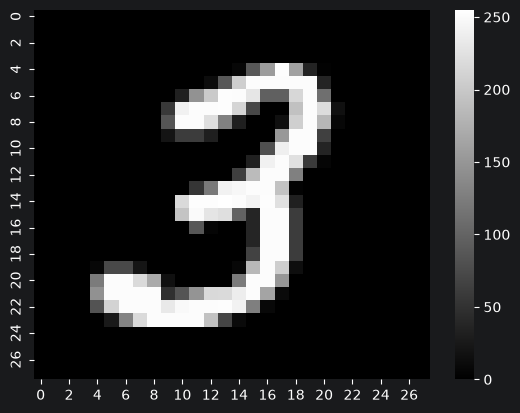

In [15]:
image = df.iloc[70,1:].values
image = image.reshape(28, 28)
sns.heatmap(image, cmap='gray')
plt.show()

In [9]:
print(
    df.info(),
    '\n-------------------------------------------------\n',
    df.isna().sum().sum(),
    '\n-------------------------------------------------\n',
)

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB
None 
-------------------------------------------------
 0 
-------------------------------------------------



In [17]:
from sklearn.model_selection import train_test_split, KFold

X = df.drop('label', axis=1)
y = df['label']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
print(len(X_train),len(X_test),len(y_train),len(y_test))

33600 8400 33600 8400


after checking and split my data and make sure it is clean , Now it is time to introcuce our model<br>
i am thinking of the tradional ones <br>
<ol>
<li> knn </li>
<li> Random Forest </li>
</ol>
either way i think i will do an A/B test

In [21]:
from sklearn.neighbors import KNeighborsClassifier as knn
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut
model = knn()
model.fit(X_train,y_train)
score_test = model.score(X_test,y_test)
score_train = model.score(X_train,y_train)
print('Test score:', score_test)
print('Train score:', score_train)

Test score: 0.9648809523809524
Train score: 0.9771726190476191


as you can see it greate for now, and there no sign of overfitting so i guess i will try to reach for the 99 for the train using the GridSearchCV but first let's try cross_validation maybe we get some other result

In [26]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5,shuffle=True,random_state=42)
loo = LeaveOneOut()
score1 = cross_val_score(model, X, y, cv=kf, n_jobs=-1)
#score2 = cross_val_score(model, X_train, y_train, cv=loo) #this take a while
print('kfold = 5', score1,score1.mean())
#print('kfold = N', score2)

kfold = 5 [0.96488095 0.96714286 0.96571429 0.96583333 0.96928571] 0.9665714285714285


In [29]:
from sklearn.model_selection import GridSearchCV
params = {
    'n_neighbors': range(3,11),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'leaf_size': range(3,11),
    'p':range(2,5),
    'metric': ['minkowski', 'euclidean', 'manhattan']
}

grid = GridSearchCV(
    estimator=model,
    param_grid=params,
    n_jobs=-1,
    scoring='accuracy',
    cv=kf,
)
grid.fit(X_train,y_train)


KeyboardInterrupt



In [27]:
print(
    model.get_params(),
    '\n------------------------------------------------\n',
    grid.best_params_,
)

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}